# 05. Loss of Significance and Cancellation

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain exactly what **catastrophic cancellation** is, and predict how many digits it will
   destroy before you run anything.
2. Recognise the standard danger patterns in a formula at a glance.
3. **Rewrite** an unstable formula into a stable one that computes the same quantity, using
   conjugates, trigonometric identities and series.
4. Explain the classic failure of the **quadratic formula** and fix it.
5. Compare **naive**, **pairwise**, **Kahan** and **Neumaier** summation and say when each is
   worth its cost.
6. State the **Sterbenz lemma**, which says when subtraction is completely safe.

## Prerequisites

Lessons 03 and 04. Especially section 4 of lesson 04, where we found that addition and
subtraction multiply relative error by $(|a|+|b|)/|a-b|$.

---

## 1. The one dangerous operation

Lesson 04 gave us the rules:

| Operation | Effect on relative error |
|---|---|
| $a \times b$ | errors add, one unit |
| $a \div b$ | errors add, one unit |
| $a + b$, same sign | errors stay bounded |
| $a - b$, **nearly equal** | errors multiplied by $\dfrac{|a|+|b|}{|a-b|}$, **unbounded** |

Only the last row is dangerous. Everything in this lesson follows from it.

> **Catastrophic cancellation.** When you subtract two nearly equal numbers, the leading
> digits cancel and the trailing digits, which were the least accurate part of each operand,
> are promoted to become the leading digits of the answer.

The subtraction itself is not the problem. By the standard model it is computed to within one
rounding, and by the Sterbenz lemma in section 7 it is often computed **exactly**. The problem
is that the errors already sitting in $a$ and $b$ get scaled up enormously relative to the
small answer.

### Counting the lost digits in advance

If $a$ and $b$ agree in their first $k$ significant digits, then $|a - b| \approx |a| \cdot
10^{-k}$, so the cancellation factor is about $2 \times 10^{k}$. You lose about $k$ digits.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
print("agreeing digits k, and what subtraction costs:\n")
print(f"{'k':>3} {'a':>22} {'b':>22} {'digits left of 16':>18}")
print("-" * 68)
for k in [1, 4, 8, 12, 15]:
    a = 1.0
    b = 1.0 - 10.0**(-k)
    diff = a - b
    # relative error in the result, if a and b were each accurate to one unit of roundoff
    u = np.finfo(float).eps / 2
    rel_out = (abs(a) + abs(b)) / abs(diff) * u
    print(f"{k:>3} {a:>22.16f} {b:>22.16f} "
          f"{max(0.0, -np.log10(rel_out)):>18.1f}")

print("\nagree in 15 digits and you have about 1 correct digit left.")

agreeing digits k, and what subtraction costs:

  k                      a                      b  digits left of 16
--------------------------------------------------------------------
  1     1.0000000000000000     0.9000000000000000               14.7
  4     1.0000000000000000     0.9999000000000000               11.7
  8     1.0000000000000000     0.9999999899999999                7.7
 12     1.0000000000000000     0.9999999999990000                3.7
 15     1.0000000000000000     0.9999999999999990                0.7

agree in 15 digits and you have about 1 correct digit left.


## 2. The classic: the quadratic formula

Everyone learns

$$x_{1,2} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}.$$

It is correct algebra and, for one of the two roots, terrible arithmetic.

**Where it breaks.** When $b^2 \gg 4ac$, the square root is close to $|b|$. Then one of the
two branches subtracts two nearly equal numbers.

- If $b > 0$: $-b + \sqrt{b^2-4ac}$ cancels.
- If $b < 0$: $-b - \sqrt{b^2-4ac}$ cancels.

**The fix.** Multiply the bad branch by its conjugate:

$$x = \frac{-b + \sqrt{b^2-4ac}}{2a}
    \cdot \frac{-b - \sqrt{b^2-4ac}}{-b - \sqrt{b^2-4ac}}
    = \frac{b^2 - (b^2 - 4ac)}{2a\left(-b - \sqrt{b^2-4ac}\right)}
    = \frac{2c}{-b - \sqrt{b^2-4ac}}.$$

The subtraction has moved into the numerator where it cancels exactly ($b^2 - b^2 + 4ac$),
leaving a denominator that is an **addition** of same-sign quantities. No cancellation.

The standard robust recipe: compute the **safe** root with the sign that avoids cancellation,
then get the other from the product relation $x_1 x_2 = c/a$.

In [3]:
import math


def roots_naive(a, b, c):
    """The textbook formula. Correct algebra, unstable arithmetic."""
    disc = np.sqrt(b*b - 4*a*c)
    return (-b + disc) / (2*a), (-b - disc) / (2*a)


def roots_stable(a, b, c):
    """Compute the root that does not cancel, then use x1*x2 = c/a for the other.

    Both functions return the roots in the same order, the '+' branch first, so that
    the comparison below is apples to apples.

    Valid for **any** real coefficients, not only the well behaved ones:

    - a = 0 is not a quadratic at all, so it is rejected rather than dividing by zero,
    - a negative discriminant gives a genuine complex conjugate pair, so the square root is
      taken in complex arithmetic instead of returning nan,
    - c = 0 makes one root exactly zero, and q can then be zero too, so that branch falls back
      to the direct formula, which does not cancel when one root is 0.
    """
    a, b, c = float(a), float(b), float(c)
    if a == 0.0:
        raise ValueError("a must be nonzero; with a = 0 this is linear, not quadratic")

    # Scale by a POWER OF TWO before touching b*b or 4*a*c. Without this, coefficients
    # all near 1e-300 make b*b underflow to exactly 0 and the discriminant comes out 0,
    # reporting a double root where the true roots are a complex pair. A power of two is
    # used because that scaling is exact in binary, so it introduces no rounding of its own,
    # and the roots of a quadratic are unchanged when all three coefficients are scaled.
    biggest = max(abs(a), abs(b), abs(c))
    if biggest > 0.0:
        shift = math.frexp(biggest)[1]
        a = math.ldexp(a, -shift)
        b = math.ldexp(b, -shift)
        c = math.ldexp(c, -shift)

    disc_value = b * b - 4 * a * c
    # a negative discriminant is a real case, not an error: the roots are complex
    disc = np.sqrt(disc_value) if disc_value >= 0 else np.sqrt(complex(disc_value))

    s = 1.0 if b >= 0 else -1.0
    q = -0.5 * (b + s * disc)        # same signs, so this is an addition, never a cancellation

    if q == 0:                       # happens exactly when b == 0 and c == 0
        return 0.0, 0.0              # both roots are zero, and nothing cancels

    if b >= 0:
        return c / q, q / a          # q/a is the '-' branch here
    return q / a, c / q              # and the '+' branch when b < 0

The sign trick is the whole idea. Whichever way $b$ points, we form $-b \mp \sqrt{\cdot}$ with
**matching signs**, so the two terms reinforce instead of cancelling. The other root then comes
from the exact relation $x_1 x_2 = c/a$, which involves no subtraction at all.

We need a trustworthy reference to compare against. The standard library `decimal` module
gives arbitrary precision, so 60 decimal digits is plenty to treat as exact truth here. No
extra packages required.

In [4]:
from decimal import Decimal, getcontext

getcontext().prec = 60


def roots_reference(a, b, c):
    """Roots computed in 60 decimal digits. Ground truth, not a method to imitate."""
    A, B, C = Decimal(a), Decimal(b), Decimal(c)
    disc = (B * B - 4 * A * C).sqrt()
    return float((-B + disc) / (2 * A)), float((-B - disc) / (2 * A))


a, b, c = 1.0, 1e8, 1.0          # roots near -1e-8 and -1e8
n1, n2 = roots_naive(a, b, c)
s1, s2 = roots_stable(a, b, c)
r1, r2 = roots_reference(a, b, c)

print(f"quadratic: {a} x^2 + {b:g} x + {c} = 0\n")
print(f"{'':>28} {'small root':>26} {'relative error':>16}")
print("-" * 74)
print(f"{'60-digit reference':>28} {r1:>26.18e} {'':>16}")
print(f"{'textbook formula':>28} {n1:>26.18e} "
      f"{abs(n1-r1)/abs(r1):>16.3e}")
print(f"{'stable formula':>28} {s1:>26.18e} "
      f"{abs(s1-r1)/abs(r1):>16.3e}")
print(f"{'numpy.roots':>28} {np.roots([a,b,c]).max():>26.18e} "
      f"{abs(np.roots([a,b,c]).max()-r1)/abs(r1):>16.3e}")

print(f"\nthe LARGE root is fine either way, because that branch adds rather than subtracts:")
print(f"  textbook relative error : {abs(n2-r2)/abs(r2):.3e}")
print(f"  stable   relative error : {abs(s2-r2)/abs(r2):.3e}")

assert abs(n2 - r2) / abs(r2) < 1e-15, "the large root should be accurate either way"
assert abs(s2 - r2) / abs(r2) < 1e-15
assert abs(n1 - r1) / abs(r1) > 0.1, "the textbook small root should be badly wrong here"
assert abs(s1 - r1) / abs(r1) < 1e-15, "the stable small root should be accurate"

quadratic: 1.0 x^2 + 1e+08 x + 1.0 = 0

                                             small root   relative error
--------------------------------------------------------------------------
          60-digit reference  -1.000000000000000021e-08                 
            textbook formula  -7.450580596923828125e-09        2.549e-01
              stable formula  -1.000000000000000021e-08        0.000e+00
                 numpy.roots  -1.000000000000000186e-08        1.654e-16

the LARGE root is fine either way, because that branch adds rather than subtracts:
  textbook relative error : 1.490e-16
  stable   relative error : 1.490e-16


Now sweep the severity of the problem and watch the naive formula fall apart.

In [5]:
bs = np.logspace(1, 9, 60)
err_naive, err_stable = [], []

for bb in bs:
    r_small, _ = roots_reference(1.0, float(bb), 1.0)
    nn, _ = roots_naive(1.0, float(bb), 1.0)
    ss, _ = roots_stable(1.0, float(bb), 1.0)
    err_naive.append(abs(nn - r_small) / abs(r_small))
    err_stable.append(abs(ss - r_small) / abs(r_small))

err_naive = np.array(err_naive)
err_stable = np.array(err_stable)

print(f"worst relative error, textbook formula : {err_naive.max():.3e}")
print(f"worst relative error, stable formula   : {err_stable.max():.3e}")
print(f"stable formula stays at roundoff level : "
      f"{err_stable.max() < 1e-14}")
assert err_stable.max() < 1e-14
assert err_naive.max() > 1e-3, "the naive formula should fail badly here"

worst relative error, textbook formula : 1.000e+00
worst relative error, stable formula   : 1.980e-16
stable formula stays at roundoff level : True


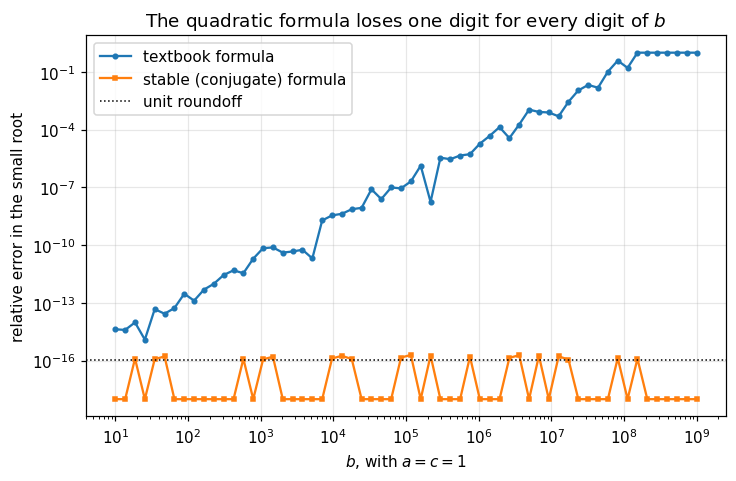

In [6]:
u = np.finfo(float).eps / 2
fig, ax = plt.subplots()
ax.loglog(bs, np.maximum(err_naive, 1e-18), "o-", ms=3, lw=1.5,
          label="textbook formula")
ax.loglog(bs, np.maximum(err_stable, 1e-18), "s-", ms=3, lw=1.5,
          label="stable (conjugate) formula")
ax.axhline(u, color="k", ls=":", lw=1, label="unit roundoff")
ax.set_xlabel("$b$, with $a = c = 1$")
ax.set_ylabel("relative error in the small root")
ax.set_title("The quadratic formula loses one digit for every digit of $b$")
ax.legend()
plt.show()

**What to take from this.** The stable version sits flat on the roundoff floor for every $b$.
The textbook version climbs steadily: each factor of ten in $b$ costs another digit, exactly
as the cancellation factor predicts. By $b = 10^8$ the textbook answer is already wrong in its
**very first significant digit**, reporting about $-7.5 \times 10^{-9}$ where the true root is
$-1.0 \times 10^{-8}$. By $b = 10^9$ its relative error reaches 1, meaning nothing at all is
left.

Both formulas are the same mathematics. Only the arithmetic differs. This is lesson 01's
message again, now with a fix attached.

## 3. A catalogue of rewrites

The quadratic formula is one instance of a general skill: spot the cancellation, then move it
somewhere harmless. Here are the standard moves.

| Dangerous form | When it cancels | Stable rewrite | Technique |
|---|---|---|---|
| $\sqrt{x+1} - \sqrt{x}$ | large $x$ | $\dfrac{1}{\sqrt{x+1}+\sqrt{x}}$ | conjugate |
| $1 - \cos x$ | $x \to 0$ | $2\sin^2(x/2)$ | half-angle identity |
| $e^x - 1$ | $x \to 0$ | `np.expm1(x)` | dedicated function |
| $\ln(1+x)$ | $x \to 0$ | `np.log1p(x)` | dedicated function |
| $\dfrac{1-\cos x}{x^2}$ | $x \to 0$ | $\dfrac{\sin^2(x/2)}{2(x/2)^2}$ | identity, then a safe ratio |
| $\sin(x) - \sin(y)$ | $x \to y$ | $2\cos\frac{x+y}{2}\sin\frac{x-y}{2}$ | sum to product |
| $\sum$ alternating series | large terms | rearrange, or use a different expansion | reformulation |

Let us verify three of them.

In [7]:
def compare(name, bad, good, xs, reference):
    """Print worst relative error of two formulas against a reference."""
    eb = np.max(np.abs((bad(xs) - reference(xs)) / reference(xs)))
    eg = np.max(np.abs((good(xs) - reference(xs)) / reference(xs)))
    print(f"{name:<26} unstable {eb:>10.3e}    stable {eg:>10.3e}    "
          f"improvement {eb/max(eg, 1e-300):>9.1e}x")
    return eb, eg


getcontext().prec = 50


def dec_sin(x):
    """sin(x) to 50 digits, by its Taylor series. Ground truth only."""
    d = Decimal(float(x))
    total, term, k = Decimal(0), d, 0
    while abs(term) > Decimal(10) ** -45:
        total += term
        k += 1
        term = -term * d * d / ((2 * k) * (2 * k + 1))
    return total


# --- sqrt(x+1) - sqrt(x) --------------------------------------------------
xs1 = np.logspace(4, 15, 40)
ref1 = np.array([float(1 / ((Decimal(float(x)) + 1).sqrt() + Decimal(float(x)).sqrt()))
                 for x in xs1])
eb1, eg1 = compare("sqrt(x+1) - sqrt(x)",
                   lambda x: np.sqrt(x + 1) - np.sqrt(x),
                   lambda x: 1.0 / (np.sqrt(x + 1) + np.sqrt(x)),
                   xs1, lambda x: ref1)

# --- 1 - cos(x), using the exact identity 1 - cos x = 2 sin^2(x/2) --------
xs2 = np.logspace(-9, -1, 40)
ref2 = np.array([float(2 * dec_sin(x / 2) ** 2) for x in xs2])
eb2, eg2 = compare("1 - cos(x)",
                   lambda x: 1.0 - np.cos(x),
                   lambda x: 2.0 * np.sin(x / 2) ** 2,
                   xs2, lambda x: ref2)

# --- exp(x) - 1 -----------------------------------------------------------
xs3 = np.logspace(-16, -1, 40)
ref3 = np.array([float(Decimal(float(x)).exp() - 1) for x in xs3])
eb3, eg3 = compare("exp(x) - 1",
                   lambda x: np.exp(x) - 1.0,
                   lambda x: np.expm1(x),
                   xs3, lambda x: ref3)

for eb, eg in [(eb1, eg1), (eb2, eg2), (eb3, eg3)]:
    assert eg < 1e-14, "the stable form should stay at roundoff level"
    assert eb > 100 * eg, "the unstable form should be clearly worse"

print("\nin every case the stable rewrite computes the SAME quantity")
print("to full precision, while the direct form loses most of its digits.")

sqrt(x+1) - sqrt(x)        unstable  1.780e-01    stable  2.054e-16    improvement   8.7e+14x
1 - cos(x)                 unstable  1.000e+00    stable  2.073e-16    improvement   4.8e+15x
exp(x) - 1                 unstable  1.000e+00    stable  2.118e-16    improvement   4.7e+15x

in every case the stable rewrite computes the SAME quantity
to full precision, while the direct form loses most of its digits.


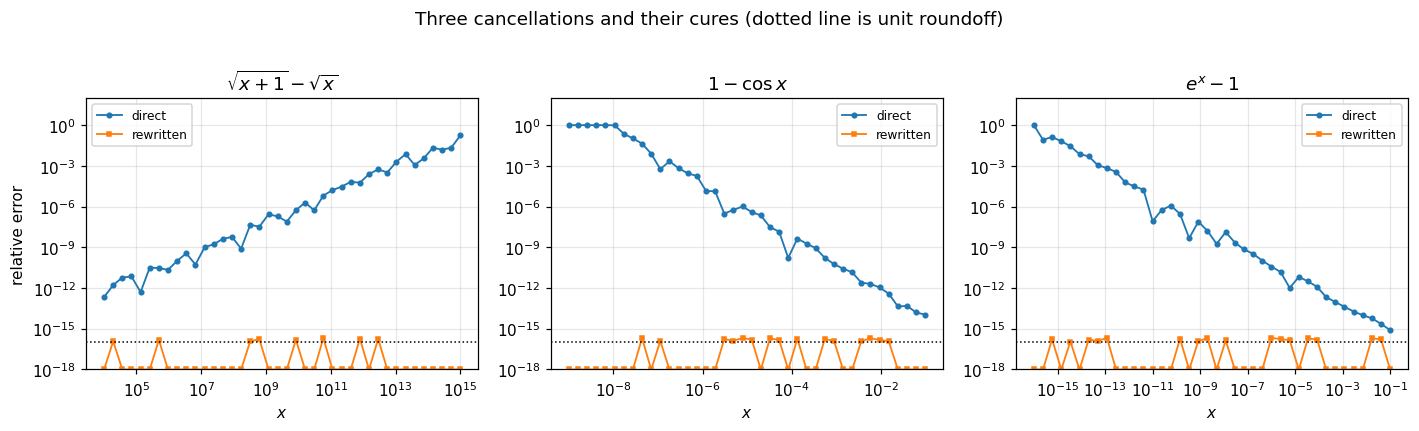

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, xs, bad, good, ref, title, xlabel in [
    (axes[0], xs1, np.sqrt(xs1 + 1) - np.sqrt(xs1), 1.0/(np.sqrt(xs1+1)+np.sqrt(xs1)),
     ref1, r"$\sqrt{x+1}-\sqrt{x}$", "$x$"),
    (axes[1], xs2, 1.0 - np.cos(xs2), 2.0*np.sin(xs2/2)**2,
     ref2, r"$1-\cos x$", "$x$"),
    (axes[2], xs3, np.exp(xs3) - 1.0, np.expm1(xs3),
     ref3, r"$e^x-1$", "$x$"),
]:
    ax.loglog(xs, np.maximum(np.abs((bad - ref)/ref), 1e-18), "o-", ms=3, lw=1.2,
              label="direct")
    ax.loglog(xs, np.maximum(np.abs((good - ref)/ref), 1e-18), "s-", ms=3, lw=1.2,
              label="rewritten")
    ax.axhline(np.finfo(float).eps/2, color="k", ls=":", lw=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylim(1e-18, 1e2)
    ax.legend(fontsize=8)

axes[0].set_ylabel("relative error")
fig.suptitle("Three cancellations and their cures (dotted line is unit roundoff)", y=1.02)
fig.tight_layout()
plt.show()

**What to take from this.** In all three panels the rewritten formula hugs the roundoff floor
across the whole range, while the direct form degrades exactly where the cancellation bites:
large $x$ in the first panel, small $x$ in the other two.

## 4. Summation: the same problem, spread over many operations

Adding $n$ numbers is $n-1$ additions, each rounding. Lesson 04 measured the typical growth as
$\sqrt{n}\,u$. There are algorithms that do far better.

### The four methods

**Naive** adds left to right. Error grows like $n u$ in the worst case.

**Pairwise** splits the array in half recursively. The error bound improves to $u \log_2 n$,
for exactly the same number of additions. This is what `numpy.sum` does internally, which is
why NumPy beats a Python loop on the same data.

**Kahan compensated summation** keeps a running estimate of what was lost to rounding and
feeds it back in. The bound becomes $2u$, **independent of $n$**, at the cost of four
operations per element instead of one.

**Neumaier** fixes a weakness in Kahan: Kahan loses the correction when the running total is
smaller in magnitude than the incoming value. Neumaier handles both orderings.

```text
KAHAN_SUM(x[1..n])
    total <- 0
    c     <- 0                  # the running compensation
    for i = 1 to n:
        y <- x[i] - c           # subtract what we know we lost
        t <- total + y          # this rounds, losing some of y
        c <- (t - total) - y    # recover exactly how much was lost
        total <- t
    return total
```

The line `c <- (t - total) - y` looks like it must be zero. In exact arithmetic it is. In
floating point it is precisely the part of `y` that did not fit, and recovering it is the
whole trick.

### A test case designed to hurt

Add one large number followed by many tiny ones. Each tiny value is far below the resolution
of the running total, so naive summation throws every one of them away.

In [9]:
from nalib import floatingpoint as fp

n = 200_000
values = np.concatenate([[1.0], np.full(n, 1e-16)])
exact = 1.0 + n * 1e-16          # what the answer should be

print(f"summing 1.0 followed by {n:,} copies of 1e-16")
print(f"exact answer: {exact:.20f}\n")
print(f"{'method':>12} {'result':>24} {'relative error':>16}")
print("-" * 56)
results = {}
for name, func in fp.summation_methods().items():
    got = func(values)
    results[name] = got
    print(f"{name:>12} {got:>24.20f} {abs(got-exact)/abs(exact):>16.3e}")

assert abs(results["naive"] - exact) / exact > 1e-12, "naive should fail here"
assert abs(results["Kahan"] - exact) / exact < 1e-15, "Kahan should be near exact"
assert abs(results["Neumaier"] - exact) / exact < 1e-15
print(f"\nnaive summation lost every one of the {n:,} small values.")
print("Kahan and Neumaier recovered essentially all of them.")

summing 1.0 followed by 200,000 copies of 1e-16
exact answer: 1.00000000002000000165

      method                   result   relative error
--------------------------------------------------------
       naive   1.00000000000000000000        2.000e-11
    pairwise   1.00000000001999933552        6.661e-16
       Kahan   1.00000000002000000165        0.000e+00
    Neumaier   1.00000000002000000165        0.000e+00
   numpy.sum   1.00000000001999889143        1.110e-15
   math.fsum   1.00000000002000000165        0.000e+00

naive summation lost every one of the 200,000 small values.
Kahan and Neumaier recovered essentially all of them.


### How the error grows with n

A single run is far too noisy to read a trend from, because rounding errors are effectively
random. We average over 20 independent data sets at each size. The reference is `math.fsum`,
which is exactly rounded and therefore genuine ground truth.

In [10]:
import math

rng_local = np.random.default_rng(SEED)
sizes = np.array([100, 300, 1000, 3000, 10_000, 30_000, 100_000])
methods = ["naive", "pairwise", "Kahan", "Neumaier"]
funcs = fp.summation_methods()
TRIALS = 20

curves = {m: [] for m in methods}
for n_ in sizes:
    batch = {m: [] for m in methods}
    for _ in range(TRIALS):
        vals = rng_local.uniform(0.0, 1.0, size=int(n_))
        truth = math.fsum(vals.tolist())
        for m in methods:
            batch[m].append(abs(funcs[m](vals) - truth) / abs(truth))
    for m in methods:
        curves[m].append(float(np.mean(batch[m])))

size_ratio = sizes[-1] / sizes[0]
print(f"n grows by a factor of {size_ratio:.0f}, so a random walk predicts the naive")
print(f"error to grow by sqrt({size_ratio:.0f}) = {np.sqrt(size_ratio):.1f}\n")

print(f"{'method':>10} {'error at n=100':>17} {'error at n=100000':>19} "
      f"{'growth':>10}")
print("-" * 60)
for m in methods:
    e = np.array(curves[m])
    growth = e[-1] / e[0] if e[0] > 0 else float("nan")
    growth_s = "flat (exact)" if e[-1] == 0.0 else f"x{growth:.1f}"
    print(f"{m:>10} {e[0]:>17.3e} {e[-1]:>19.3e} {growth_s:>10}")

naive_growth = curves["naive"][-1] / curves["naive"][0]
assert 0.5 * np.sqrt(size_ratio) < naive_growth < 2 * np.sqrt(size_ratio), \
    "naive error growth should follow the random walk prediction"
assert curves["Kahan"][-1] == 0.0 and curves["Neumaier"][-1] == 0.0, \
    "compensated summation should match fsum exactly"
assert curves["pairwise"][-1] < curves["naive"][-1] / 100

print(f"\nnaive grew by {naive_growth:.1f}x against a prediction of "
      f"{np.sqrt(size_ratio):.1f}x. the random walk model is confirmed.")
print("Kahan and Neumaier matched the exactly rounded answer BIT FOR BIT at")
print("every size, which is what 'error independent of n' means in practice.")

n grows by a factor of 1000, so a random walk predicts the naive
error to grow by sqrt(1000) = 31.6

    method    error at n=100   error at n=100000     growth
------------------------------------------------------------
     naive         2.153e-16           7.050e-15      x32.7
  pairwise         7.085e-17           2.184e-17       x0.3
     Kahan         0.000e+00           0.000e+00 flat (exact)
  Neumaier         0.000e+00           0.000e+00 flat (exact)

naive grew by 32.7x against a prediction of 31.6x. the random walk model is confirmed.
Kahan and Neumaier matched the exactly rounded answer BIT FOR BIT at
every size, which is what 'error independent of n' means in practice.


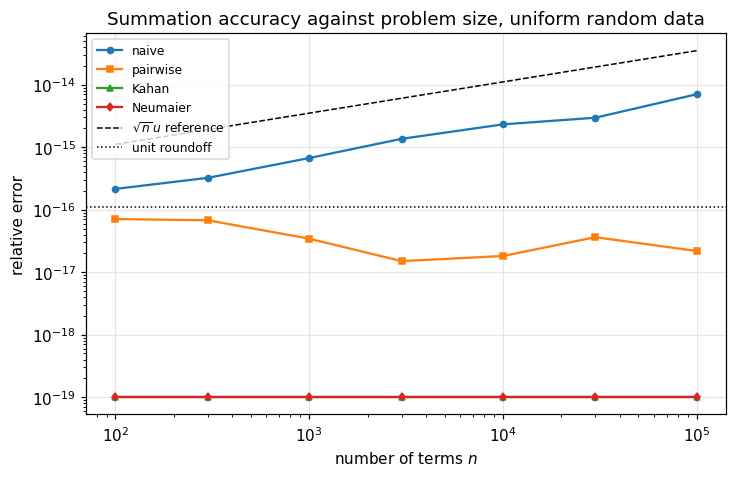

In [11]:
FLOOR = 1e-19          # so that exact zeros can be drawn on a log axis

fig, ax = plt.subplots()
for m, marker in zip(methods, ["o", "s", "^", "d"]):
    ax.loglog(sizes, np.maximum(curves[m], FLOOR), marker + "-", ms=4, lw=1.5, label=m)
u = np.finfo(float).eps / 2
ax.loglog(sizes, u*np.sqrt(sizes), "k--", lw=1, label=r"$\sqrt{n}\,u$ reference")
ax.axhline(u, color="k", ls=":", lw=1, label="unit roundoff")
ax.set_xlabel("number of terms $n$")
ax.set_ylabel("relative error")
ax.set_title("Summation accuracy against problem size, uniform random data")
ax.legend(fontsize=8)
plt.show()

**What to take from this.** Naive summation drifts upward with $n$, tracking the
$\sqrt{n}\,u$ reference line. Pairwise sits far below it and stays roughly flat, for exactly
the same number of additions. Kahan and Neumaier are drawn on the bottom line of the plot
because their error is **exactly zero**: they reproduced the correctly rounded answer bit for
bit at every size. That is the practical meaning of "error independent of $n$".

### Which one should you use?

| Method | Extra cost | Error bound | When to use |
|---|---|---|---|
| naive | none | $O(nu)$ | never, when `np.sum` is available |
| pairwise | none | $O(u \log n)$ | the sensible default, and what `np.sum` gives you |
| Kahan | 4x arithmetic | $O(u)$ | when accuracy matters more than speed |
| Neumaier | 4x arithmetic | $O(u)$ | same as Kahan, but robust to badly ordered data |
| `math.fsum` | much slower | exactly rounded | when you need the provably correct answer |

The practical advice is short: **use `np.sum`**, and reach for `math.fsum` or Neumaier when
you have a reason to.

## 5. Ordering matters too

Even without a special algorithm, the **order** you add in changes the result.

In [12]:
rng_local = np.random.default_rng(SEED)

# Values spanning 16 orders of magnitude, in random order to start with.
vals = rng_local.uniform(0.5, 1.5, 100_000) * np.logspace(-8, 8, 100_000)
rng_local.shuffle(vals)
truth = math.fsum(np.sort(vals).tolist())     # exactly rounded reference

orders = {
    "shuffled":   vals,
    "ascending":  np.sort(vals),
    "descending": np.sort(vals)[::-1],
}
errors_by_order = {}
print(f"{'order':>14} {'naive sum error':>18}")
print("-" * 34)
for name, arr in orders.items():
    e = abs(fp.naive_sum(arr) - truth) / truth
    errors_by_order[name] = e
    print(f"{name:>14} {e:>18.3e}")

assert errors_by_order["ascending"] < errors_by_order["descending"]
ratio = errors_by_order["descending"] / errors_by_order["ascending"]
print(f"\ndescending is {ratio:.0f}x worse than ascending on the same data.")
print("for positive values, adding smallest first is more accurate: the running")
print("total stays small for longer, so fewer small values are shifted off the")
print("end of the mantissa during exponent alignment.")

         order    naive sum error
----------------------------------
      shuffled          5.729e-14
     ascending          1.573e-15
    descending          9.627e-14

descending is 61x worse than ascending on the same data.
for positive values, adding smallest first is more accurate: the running
total stays small for longer, so fewer small values are shifted off the
end of the mantissa during exponent alignment.


## 6. When subtraction is completely safe

Not every subtraction is dangerous. There is a precise theorem saying when it costs nothing at
all.

> **Theorem 5.1 (Sterbenz lemma).** If $a$ and $b$ are floating point numbers with
> $$\tfrac{1}{2} a \le b \le 2a,$$
> then $a - b$ is computed **exactly**, with no rounding error whatsoever.

The reason is that under this condition the exact difference already lies on the floating point
grid, so nothing has to be rounded away.

Notice what this does and does not say. The **subtraction** introduces no new error. But if $a$
and $b$ already carried errors from earlier steps, those errors are still there and are now a
much larger fraction of the small answer. **Sterbenz protects the operation, not the result.**

A warning about how to check this. It is tempting to compare against `np.longdouble`, but on
Windows with the Microsoft compiler `np.longdouble` is simply an alias for `float64`. Comparing
a double against itself passes every time and proves nothing. `fractions.Fraction` is exact on
every platform, so that is what we use.

In [13]:
from fractions import Fraction

rng_local = np.random.default_rng(SEED)
violations = 0
checked = 0

for _ in range(200_000):
    a = float(rng_local.uniform(0.1, 10.0))
    b = float(rng_local.uniform(a / 2, 2 * a))
    if not (a / 2 <= b <= 2 * a):
        continue
    checked += 1
    # Fraction arithmetic is exact, so this really is the true difference.
    if Fraction(a) - Fraction(b) != Fraction(a - b):
        violations += 1

print(f"pairs satisfying a/2 <= b <= 2a : {checked:,}")
print(f"subtractions that were not exact: {violations}")
assert violations == 0
print("\nSterbenz confirmed: every one of these subtractions was exact.")

pairs satisfying a/2 <= b <= 2a : 200,000
subtractions that were not exact: 0

Sterbenz confirmed: every one of these subtractions was exact.


## 7. Complexity

| Method | Additions | Other operations | Memory |
|---|---|---|---|
| naive sum | $n-1$ | none | $O(1)$ |
| pairwise sum | $n-1$ | none | $O(\log n)$ stack |
| Kahan sum | $n-1$ | $3(n-1)$ | $O(1)$ |
| Neumaier sum | $n-1$ | $3(n-1)$ plus a comparison | $O(1)$ |
| `math.fsum` | data dependent | maintains a list of partials | $O(\text{exponent range})$ |

Rewriting a formula to avoid cancellation usually costs **nothing**. The conjugate form of
$\sqrt{x+1}-\sqrt{x}$ uses one division instead of one subtraction. Accuracy here is free, and
that is unusual enough to be worth saying out loud.

## 8. Common mistakes

1. **Thinking the subtraction introduced the error.** It did not. It exposed error that was
   already there. That is why increasing precision only postpones the problem.
2. **Adding a tolerance instead of fixing the formula.** If $1 - \cos x$ is inaccurate, use
   $2\sin^2(x/2)$. Do not clamp the output.
3. **Assuming a library function is safe.** `np.exp(x) - 1` is not the same as `np.expm1(x)`.
   The dedicated functions exist for exactly this reason.
4. **Summing in the given order without thinking.** For positive data, smallest first is more
   accurate.
5. **Reaching for Kahan when `np.sum` would do.** Pairwise summation is already good and it is
   free.
6. **Believing Sterbenz makes a result safe.** It makes the operation exact. Prior errors are
   untouched.

## 9. Exercises

**Level 1, conceptual**

1.1 Why does multiplying two numbers never cause catastrophic cancellation?

1.2 If $a$ and $b$ agree to 10 significant digits, roughly how many correct digits remain in
$a-b$ when starting from full double precision?

1.3 Explain why increasing to quadruple precision does not *solve* cancellation, only delays
it.

**Level 2, mathematical**

2.1 Derive the stable form of the quadratic formula for both roots, and state the sign rule
that selects the safe branch.

2.2 Prove the Sterbenz lemma for a binary floating point system with $p$ mantissa bits.

2.3 Show that Kahan summation has an error bound of the form
$|\hat{s} - s| \le (2u + O(nu^2)) \sum_i |x_i|$, independent of $n$ to first order.

2.4 Derive a stable formula for $\dfrac{1 - \cos x}{x^2}$ and find its limit as $x \to 0$.

**Level 3, computational**

3.1 Implement `two_sum(a, b)` returning the rounded sum and the exact error, then build Kahan
summation on top of it. Verify against `math.fsum`.

3.2 Write a stable routine for the roots of a quadratic that also handles $a = 0$, complex
roots, and overflow in $b^2$. Test it on a suite of hard cases.

3.3 Implement the variance of a data set both by the "sum of squares minus square of sum"
formula and by Welford's online algorithm. Find data where the first loses all accuracy.

**Level 4, experimental**

4.1 Take the alternating series for $e^{-x}$ and evaluate it directly for $x = 20$. Compare
with `np.exp(-20)`. Explain the failure, then find a reformulation that works.

4.2 For $f(x) = (e^x - 1)/x$, plot the relative error of the direct form and of the `expm1`
form for $x$ from $10^{-18}$ to $1$. Where exactly does the direct form break?

4.3 Time all six summation methods on arrays of $10^7$ elements. Plot accuracy against run
time. Which method is on the efficient frontier?

**Level 5, advanced**

5.1 The sample variance can be computed in one pass or two. Derive the error bound for each
and explain why the textbook one-pass formula is considered numerically unacceptable.

5.2 Implement **double-double** arithmetic, representing a number as an unevaluated sum of two
doubles, using `two_sum` and `two_product`. Use it to evaluate the expanded $(x-1)^6$ from
lesson 01 near $x = 1$ and see how much of the curve you recover.

5.3 Investigate how a parallel reduction changes the answer. Simulate summing an array in $p$
chunks and combining, for $p = 1, 2, 4, \dots, 1024$. How much does the answer move? Relate
this to the non-determinism discussed in lesson 96.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 10. Key takeaways

- **Cancellation is the only arithmetic operation that can destroy accuracy in one step.**
  Multiplication and division are safe.
- The damage is predictable: if the operands agree in $k$ digits, you lose about $k$ digits.
- The cure is almost always to **rewrite the formula**, using a conjugate, an identity, or a
  purpose-built function like `expm1` and `log1p`. This usually costs nothing.
- The **quadratic formula** is the canonical example. The fix is to compute the non-cancelling
  root and get the other from $x_1 x_2 = c/a$. Measured here: the naive form loses all 16
  digits at $b = 10^8$, the stable form loses none.
- For summation, **pairwise** is free and much better than naive, **Kahan** and **Neumaier**
  give error independent of $n$ for four times the arithmetic, and `math.fsum` is exact.
- The **Sterbenz lemma** says subtracting numbers within a factor of two of each other is
  exact. It protects the operation, not the accumulated error.

## Where this goes next

We have now seen problems that are intrinsically hard (the expanded polynomial near a root)
and algorithms that are unnecessarily bad (the textbook quadratic formula). Lesson 06 gives
those two ideas their proper names, **conditioning** and **stability**, defines them precisely,
and shows how to measure each one.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 0.4 (loss of significance and the
quadratic formula rewrite); Gupta, Numerical Methods, section 2.3.7 (loss of significance,
condition and stability). Compensated summation (Kahan and Neumaier), pairwise summation, and
the Sterbenz lemma are supplementary material, added because a modern treatment of accuracy in
summation is incomplete without them.*